# Hito 1: Análisis Exploratorio de Datos (EDA) y Preparación del Dataset
## Proyecto: HedgeMind-NVDA
**Autor:** Fausto Jara Buncay  
**Estructura:** Conexión híbrida en la nube (Amazon RDS Cloud Data) con procesamiento local acelerado por hardware.

Este cuaderno aborda formalmente la Etapa 3 (Análisis Exploratorio de Datos) y la Etapa 4 (Preparación del conjunto de datos) siguiendo las directrices del marco académico establecido.

In [1]:
# ==============================================================================
# IMPORTE DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import os
import sys
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Cargar variables de entorno perimetrales
load_dotenv()

# Configuración estética de grado de publicación para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': [12, 6],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Verificación de la infraestructura de cómputo local
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"🏎️ ACELERACIÓN POR HARDWARE DETECTADA: {torch.cuda.get_device_name(0)}")
    print(f"📦 CUDA Versión: {torch.version.cuda}")
else:
    print("⚠️ ALERTA: Procesamiento degradado a CPU.")

🏎️ ACELERACIÓN POR HARDWARE DETECTADA: NVIDIA GeForce RTX 4060 Laptop GPU
📦 CUDA Versión: 12.4


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Inspección Inicial
Procedemos a realizar la conexión directa con el Data Warehouse en Amazon RDS para extraer el dataset unificado de NVIDIA (`NVDA`) e inspeccionar su estructura interna, dimensiones y tipado de variables.

In [2]:
# ==============================================================================
# INGESTA DESDE DATA WAREHOUSE (AMAZON RDS CLOUD)
# ==============================================================================
db_user = os.getenv("DB_USER")
db_pass = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT") # 3306
db_name = os.getenv("DB_NAME")

conexion_str = f"mysql+mysqlconnector://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}"
engine = create_engine(conexion_str)

# Consulta SQL de extracción
query = "SELECT * FROM dataset_nvda_unificado"
df_eda = pd.read_sql(query, con=engine, index_col='fecha')
df_eda.index = pd.to_datetime(df_eda.index)

print(f"✅ Extracción completada. Dimensiones del dataset unificado: {df_eda.shape}\n")
print("=== MOSTRANDO LOS PRIMEROS 5 REGISTROS DEL DATASET ===")
print(df_eda.head(5))

print("\n=== ANÁLISIS DE CONTENIDO Y TIPADO DE CADA COLUMNA ===")
print(df_eda.info())

✅ Extracción completada. Dimensiones del dataset unificado: (6862, 6)

=== MOSTRANDO LOS PRIMEROS 5 REGISTROS DEL DATASET ===
            close_price  trading_volume     rsi_14  sentiment_score  \
fecha                                                                 
1999-02-10     0.034738       148224000  42.683161        -0.575322   
1999-02-11     0.037722       132240000  50.264076        -0.636350   
1999-02-12     0.039871       109728000  45.976953        -0.633191   
1999-02-16     0.040109       211008000  55.033202        -0.391516   
1999-02-17     0.037960        67728000  49.396212         0.049513   

            news_volume  target_return  
fecha                                   
1999-02-10           75       0.085904  
1999-02-11           14       0.056968  
1999-02-12           38       0.005978  
1999-02-16           12      -0.053577  
1999-02-17           45       0.015723  

=== ANÁLISIS DE CONTENIDO Y TIPADO DE CADA COLUMNA ===
<class 'pandas.core.frame.DataFra

### 3.2 Estadísticas Descriptivas
Para comprender la distribución, tendencia central y dispersión del mercado financiero y del flujo cualitativo extraído de MongoDB, calculamos los momentos estadísticos clave (Media, Mediana, Moda, Desviación Estándar y Percentiles).

In [3]:
# ==============================================================================
# CÁLCULO DE MOMENTOS ESTADÍSTICOS Y TENDECIAS CENTRALES
# ==============================================================================
# Obtención de estadísticas base con percentiles extendidos
stats_df = df_eda.describe(percentiles=[.25, .50, .75, .90, .95])

# Cálculo explícito de la Moda (frecuencia estadística)
modas = df_eda.mode().iloc[0]
stats_df.loc['moda'] = modas

print("=== MATRIZ DE ESTADÍSTICAS DESCRIPTIVAS CONSOLIDADAS ===")
print(stats_df.round(4))

=== MATRIZ DE ESTADÍSTICAS DESCRIPTIVAS CONSOLIDADAS ===
       close_price  trading_volume     rsi_14  sentiment_score  news_volume  \
count    6862.0000    6.862000e+03  6862.0000        6862.0000    6862.0000   
mean       16.1004    5.810357e+08    53.7973          -0.0067      50.2961   
std        41.1795    4.285571e+08    17.2530           0.5790      28.4749   
min         0.0313    1.968000e+07     2.9787          -1.0000       1.0000   
25%         0.2662    3.158980e+08    41.4216          -0.5092      25.0000   
50%         0.4559    4.823400e+08    53.9764          -0.0065      51.0000   
75%         5.9946    7.152030e+08    66.1877           0.4965      75.0000   
90%        43.9071    1.042309e+09    76.4401           0.7959      89.0000   
95%       130.7130    1.309355e+09    81.7826           0.9017      94.0000   
max       235.7400    9.230856e+09    99.4290           0.9994      99.0000   
moda        0.0401    4.517280e+08    35.6223          -1.0000      86.000

### 3.3 Visualización de Datos e Identificación de Patrones y Anomalías
Utilizamos una arquitectura de subplots para mapear la distribución de frecuencias, la dispersión del volumen negociado, la detección geométrica de valores atípicos (*Outliers*) y la matriz de correlación inicial.

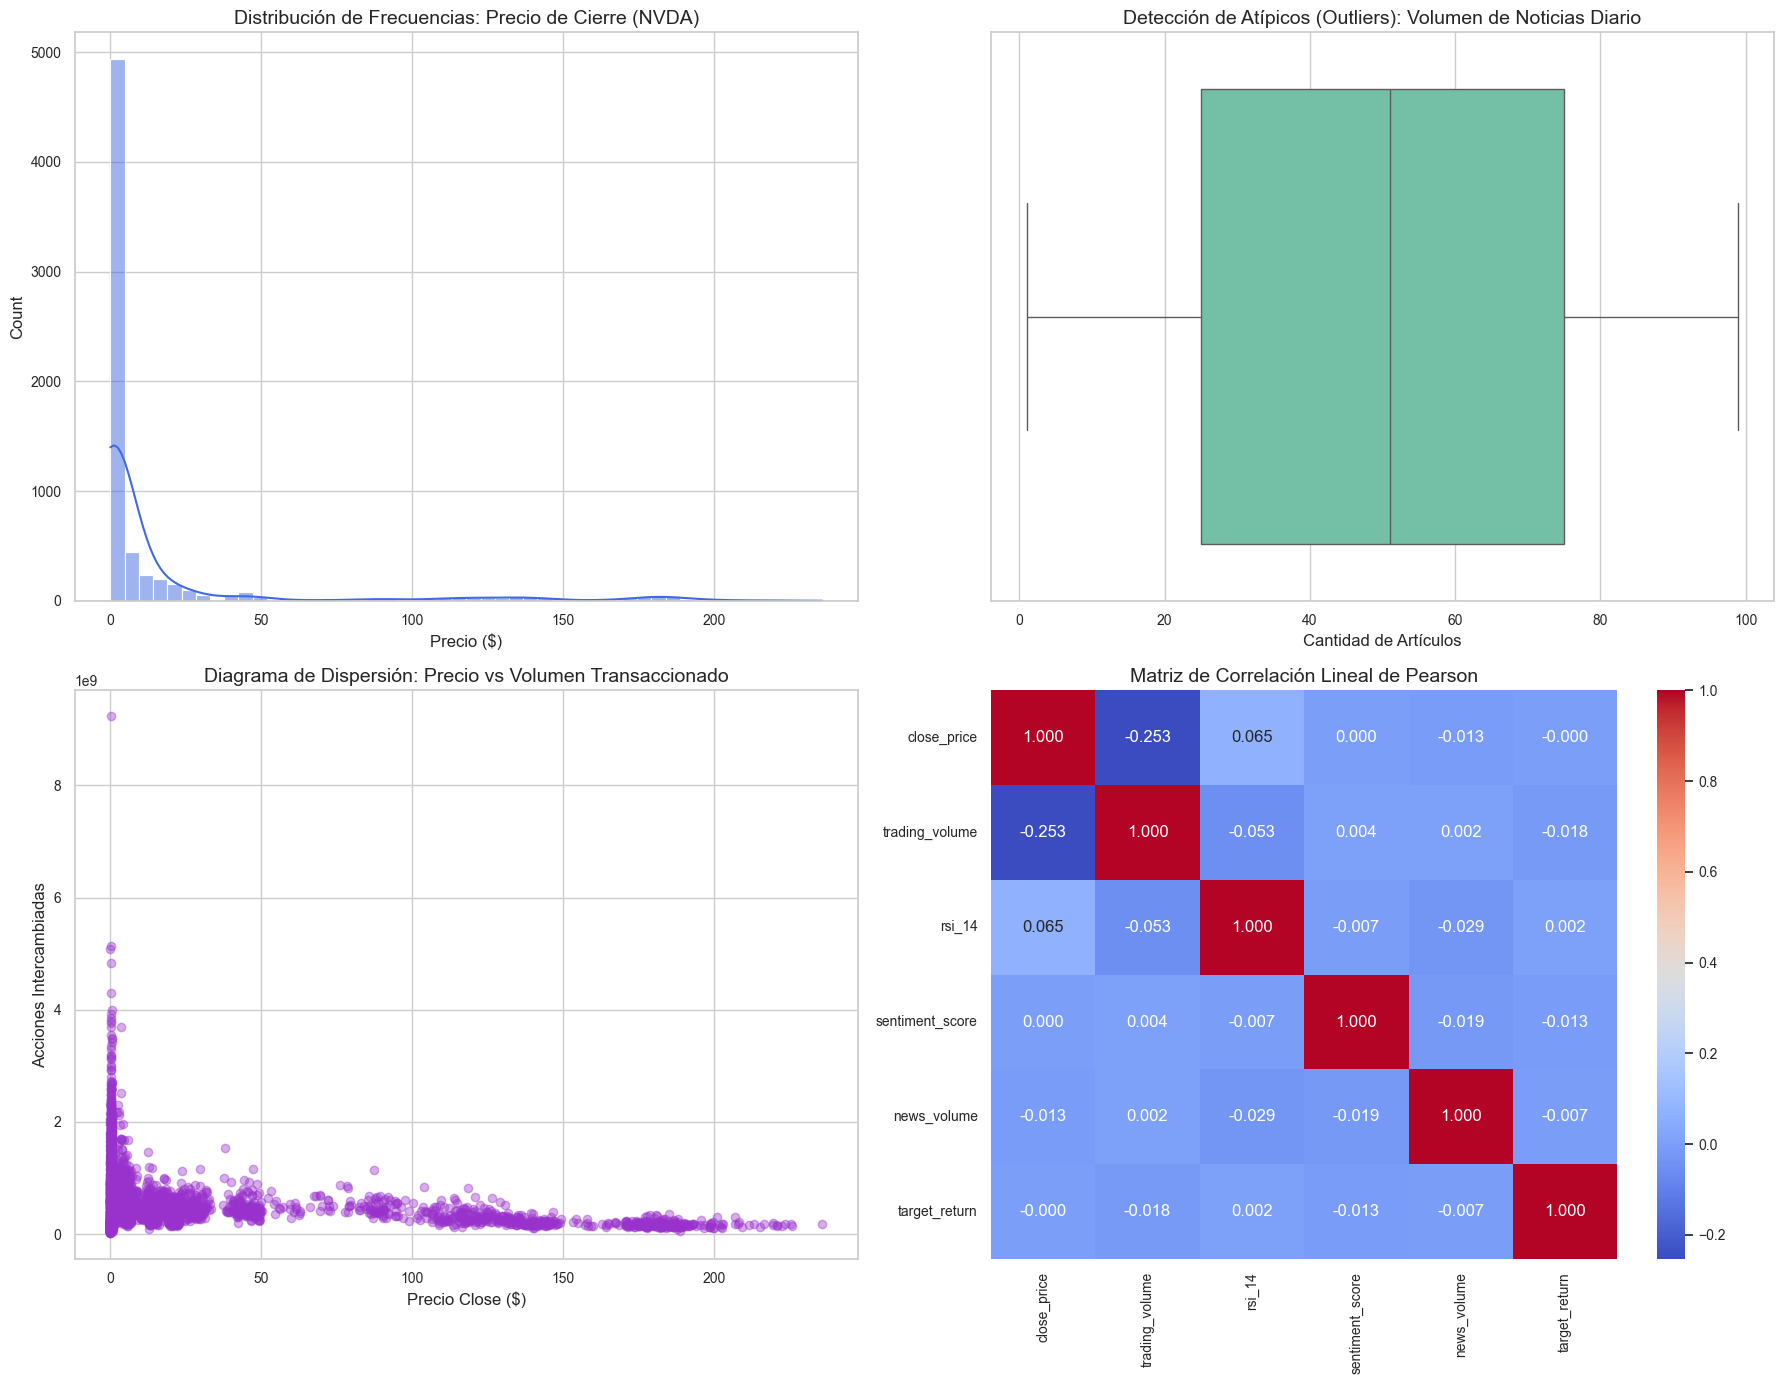

In [4]:
# ==============================================================================
# ARQUITECTURA DE VISUALIZACIÓN MULTI-PANEL (EDA)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Histograma: Distribución de Precios de Cierre
sns.histplot(df_eda['close_price'], kde=True, ax=axes[0,0], color='royalblue', bins=50)
axes[0,0].set_title('Distribución de Frecuencias: Precio de Cierre (NVDA)')
axes[0,0].set_xlabel('Precio ($)')

# 2. Boxplot: Identificación geométrica de anomalías en Volumen Informativo
sns.boxplot(x=df_eda['news_volume'], ax=axes[0,1], color='mediumaquamarine')
axes[0,1].set_title('Detección de Atípicos (Outliers): Volumen de Noticias Diario')
axes[0,1].set_xlabel('Cantidad de Artículos')

# 3. Diagrama de Dispersión: Análisis de Liquidez (Precio vs Volumen de Mercado)
axes[1,0].scatter(df_eda['close_price'], df_eda['trading_volume'], alpha=0.4, color='darkorchid')
axes[1,0].set_title('Diagrama de Dispersión: Precio vs Volumen Transaccionado')
axes[1,0].set_xlabel('Precio Close ($)')
axes[1,0].set_ylabel('Acciones Intercambiadas')

# 4. Gráfico de Correlación Lineal (Pearson)
sns.heatmap(df_eda.corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[1,1], cbar=True)
axes[1,1].set_title('Matriz de Correlación Lineal de Pearson')

plt.tight_layout()
plt.show()

## 4. Preparación del Conjunto de Datos (Data Preparation)

### 4.1 Integración y Resolución de Inconsistencias
Aunque la unificación inicial se gestionó en la tubería híbrida, aplicamos salvaguardas estrictas en memoria para garantizar la ausencia de fechas duplicadas, asegurar el tipado correcto de variables numéricas y controlar la integridad referencial.

In [5]:
# ==============================================================================
# RESOLUCIÓN DE INCONSISTENCIAS Y VERIFICACIÓN DE INTEGRIDAD
# ==============================================================================
df_prep = df_eda.copy()

# 1. Control de registros duplicados en el índice temporal
duplicados = df_prep.index.duplicated().sum()
print(f"Registros cronológicos duplicados detectados: {duplicados}")
df_prep = df_prep[~df_prep.index.duplicated(keep='first')]

# 2. Adecuación estricta de tipos de datos para cómputo tensorial
df_prep['close_price'] = df_prep['close_price'].astype(np.float32)
df_prep['trading_volume'] = df_prep['trading_volume'].astype(np.float64)
df_prep['sentiment_score'] = df_prep['sentiment_score'].astype(np.float32)
df_prep['news_volume'] = df_prep['news_volume'].astype(np.int32)

# 3. Tratamiento formal de valores faltantes (Imputación por Mediana)
# Justificación académica: La mediana previene el sesgo frente a distribuciones asimétricas.
print(f"Valores nulos pre-imputación:\n{df_prep.isnull().sum()}")
for col in df_prep.columns:
    if df_prep[col].isnull().sum() > 0:
        mediana_val = df_prep[col].median()
        df_prep[col].fillna(mediana_val, inplace=True)

Registros cronológicos duplicados detectados: 0
Valores nulos pre-imputación:
close_price        0
trading_volume     0
rsi_14             0
sentiment_score    0
news_volume        0
target_return      0
dtype: int64


### 4.2 Tratamiento de Valores Atípicos (Outliers)
Para evitar distorsiones en los gradientes del modelo de Inteligencia Artificial debido a picos históricos extremos de volumen informático, aplicamos una técnica de acotamiento (*Capping*) basada en el Rango Intercuartílico (IQR).

In [6]:
# ==============================================================================
# TRATAMIENTO DE OUTLIERS MEDIANTE ACOTAMIENTO (IQR CAPPING)
# ==============================================================================
Q1 = df_prep['news_volume'].quantile(0.25)
Q3 = df_prep['news_volume'].quantile(0.75)
IQR = Q3 - Q1

umbral_superior = Q3 + 1.5 * IQR
print(f"📈 Umbral estadístico superior establecido para News Volume: {umbral_superior}")

# Aplicación del Capping estadístico
df_prep['news_volume'] = np.where(df_prep['news_volume'] > umbral_superior, umbral_superior, df_prep['news_volume'])
print("✅ Valores atípicos suavizados correctamente dentro de los límites del IQR.")

📈 Umbral estadístico superior establecido para News Volume: 150.0
✅ Valores atípicos suavizados correctamente dentro de los límites del IQR.


### 4.3 Ingeniería de Características (Feature Engineering)
En esta fase creamos nuevas variables para enriquecer el contexto temporal, capturar dinámicas no lineales mediante transformaciones matemáticas, discretizar variables informativas complejas y codificar características estructurales.

In [7]:
# ==============================================================================
# INGENIERÍA DE CARACTERÍSTICAS AVANZADA
# ==============================================================================
df_features = df_prep.copy()

# 1. Descomposición de variables temporales (Extracción cronológica)
df_features['Year'] = df_features.index.year
df_features['Month'] = df_features.index.month
df_features['Day'] = df_features.index.day

# 2. Transformaciones matemáticas de estabilidad y volatilidad
df_features['Log_Volume'] = np.log1p(df_features['trading_volume']) # Suavizado logarítmico
df_features['Price_Square'] = df_features['close_price'] ** 2       # Variable cuadrática

# 3. Discretización de variables continuas (Segmentación por cuantiles)
df_features['News_Intensity_Level'] = pd.qcut(df_features['news_volume'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# 4. Creación de variables cruzadas de interacción
df_features['Sentiment_Impact_Factor'] = df_features['sentiment_score'] * df_features['news_volume']

# 5. Encoding de variables categóricas complejas (One-Hot Encoding)
# Justificación: Evita la asignación implícita de un orden jerárquico inexistente.
df_features = pd.get_dummies(df_features, columns=['News_Intensity_Level'], drop_first=True)

print("=== LISTADO DE CARACTERÍSTICAS TRAS INGENIERÍA DE VARIABLES ===")
print(df_features.columns.tolist())

=== LISTADO DE CARACTERÍSTICAS TRAS INGENIERÍA DE VARIABLES ===
['close_price', 'trading_volume', 'rsi_14', 'sentiment_score', 'news_volume', 'target_return', 'Year', 'Month', 'Day', 'Log_Volume', 'Price_Square', 'Sentiment_Impact_Factor', 'News_Intensity_Level_Medio', 'News_Intensity_Level_Alto']


### 4.4 División del Dataset y Escalado de Características
**Justificación metodológica crítica:** Al trabajar con series temporales, está estrictamente prohibido aplicar un remuestreo aleatorio (*Random Shuffle*), ya que provocaría *Data Leakage* (filtración de datos del futuro hacia el pasado). Realizamos una división secuencial indexada (80% Entrenamiento, 20% Test) y estandarizamos las variables de entrada basándonos exclusivamente en los parámetros del conjunto de entrenamiento.

In [8]:
# ==============================================================================
# DIVISIÓN TEMPORAL Y ESCALADO PERIMETRAL (PREVENCIÓN DE DATA LEAKAGE)
# ==============================================================================
# Separación de variables independientes (X) y variable objetivo (y)
X = df_features.drop(columns=['target_return'])
y = df_features['target_return']

# Punto de corte secuencial (80%)
split_idx = int(len(df_features) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Escalado de características por Estandarización Z-Score
scaler = StandardScaler()

# Ajuste exclusivo con datos de entrenamiento para mantener la integridad del test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== RESUMEN OPERATIVO DEL DATASET FINAL ===")
print(f"Dimensiones Matrices Entrenamiento (X_train): {X_train_scaled.shape}")
print(f"Dimensiones Matrices Test (X_test):           {X_test_scaled.shape}")
print(f"Línea de tiempo de Entrenamiento:             {X_train.index[0].strftime('%Y-%m-%d')} a {X_train.index[-1].strftime('%Y-%m-%d')}")
print(f"Línea de tiempo de Validación (Test):          {X_test.index[0].strftime('%Y-%m-%d')} a {X_test.index[-1].strftime('%Y-%m-%d')}")

=== RESUMEN OPERATIVO DEL DATASET FINAL ===
Dimensiones Matrices Entrenamiento (X_train): (5489, 13)
Dimensiones Matrices Test (X_test):           (1373, 13)
Línea de tiempo de Entrenamiento:             1999-02-10 a 2020-12-01
Línea de tiempo de Validación (Test):          2020-12-02 a 2026-05-21
